# Lab 4 · A VAE for Spectra QC, Anomaly Detection & Generation
**MSACL · DS301 Deep Learning · Segment 4 · Lab 4**

In Lecture 11 you met the **autoencoder** — a network that squeezes a spectrum through a
narrow **bottleneck** and rebuilds it — and its smoother cousin the **variational autoencoder
(VAE)**, which learns an *organized* latent space you can sample and walk through.

This lab makes those ideas real on the **same DRIAMS MALDI-TOF spectra** from Lab 2. You will:

- train a VAE on **normal** (susceptible) spectra only,
- use **reconstruction error** as an **anomaly / QC score** to flag odd spectra,
- **plot the 2-D latent space** and compare a VAE's map against a plain autoencoder's, and
- **interpolate** between two spectra — watch one morph into another.

**You fill in exactly three short pieces**: the bottleneck size, the combined loss line, and
the anomaly threshold. Everything else — encoder, decoder, and the reparameterization trick —
runs as-is.


## The setup: what "normal" and "anomaly" mean here

An autoencoder that has only ever *seen* one kind of spectrum learns to rebuild that kind
well — and rebuilds anything **unfamiliar** badly. That **reconstruction error** is our
anomaly score (Lecture 11): high error = "this doesn't look like what I was trained on."

We treat the **susceptible** spectra (697 of them) as **normal**, train the VAE only on a
*training split* of them, then score everything held out. As an honest stand-in for "a
spectrum the detector has never seen," we also feed in the **resistant** spectra.

> **Be honest about what this does (and doesn't) do.** Reconstruction-error anomaly detection
> is **novelty / QC detection** — it flags spectra unlike the training set. It is *not* a
> resistance classifier and will **not** cleanly separate resistant from susceptible: the two
> look very similar (you saw that in Lab 2). The teaching point is the **method** and that the
> **threshold is a sensitivity/specificity choice** — the same trade-off as Lecture 10's
> threshold ladder, now for QC flags instead of disease calls.


In [1]:
# Read and run — no need to edit.
import os
import urllib.request
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # this lab runs fine on CPU too
print("Libraries ready. Device:", DEVICE)


Libraries ready. Device: cpu


## Step 1 · Load the spectra *(runs for you)*

In [2]:
# Read and run — no need to edit.  (same DRIAMS slice as Lab 2)
# The data lives in this repo for local development; in Colab it downloads instead.
LOCAL_PATH = Path("../../data/slices/driams_c_saureus_oxacillin.npz")
RAW_URL = "https://raw.githubusercontent.com/<ORG>/<REPO>/main/data/slices/driams_c_saureus_oxacillin.npz"

if LOCAL_PATH.exists():
    npz_path = LOCAL_PATH
else:
    npz_path = Path("driams_c_saureus_oxacillin.npz")
    if not npz_path.exists():
        urllib.request.urlretrieve(RAW_URL, npz_path)

data = np.load(npz_path)
X = data["X"].astype("float32")   # (738, 6000) TIC-normalized MALDI-TOF intensities
y = data["y"].astype("int64")     # 0 = susceptible (we call this NORMAL), 1 = resistant

# per-spectrum max-normalize to 0..1 (matches Lab 2; friendly for a 0..1 decoder output)
X = X / X.max(axis=1, keepdims=True)

n_sus, n_res = int((y == 0).sum()), int((y == 1).sum())
print("Spectra:", X.shape, "| normal/susceptible:", n_sus, "| resistant:", n_res)


Spectra: (738, 6000) | normal/susceptible: 697 | resistant: 41


## Step 2 · Build the "normal" training set *(runs for you)*

We split the **susceptible** spectra 80/20: 80% **train the VAE**, 20% are **held-out normal**
we can score later. The **resistant** spectra are never seen in training — they join the
held-out set as our "unfamiliar" stand-ins. This mirrors real QC: you build the detector on
runs you *trust*, then watch new runs stream in.


In [3]:
# Read and run — no need to edit.
# (a knob or two here so a reduced smoke run stays fast; defaults are the full lab)
MAX_NORMAL_TRAIN = None    # None = use all normal-train spectra

sus_idx = np.where(y == 0)[0]
res_idx = np.where(y == 1)[0]
np.random.shuffle(sus_idx)

n_train = int(0.8 * len(sus_idx))
train_normal_idx = sus_idx[:n_train]
heldout_normal_idx = sus_idx[n_train:]
if MAX_NORMAL_TRAIN is not None:
    train_normal_idx = train_normal_idx[:MAX_NORMAL_TRAIN]

# the scoring set = held-out normal + all resistant (label 0 = normal, 1 = resistant)
score_idx = np.concatenate([heldout_normal_idx, res_idx])
score_label = y[score_idx]

X_train = torch.tensor(X[train_normal_idx], device=DEVICE)          # (n_train, 6000) normal only
X_score = torch.tensor(X[score_idx], device=DEVICE)                 # held-out normal + resistant

print(f"VAE train (normal only): {len(train_normal_idx)} spectra")
print(f"scoring set: {len(score_idx)} spectra "
      f"({int((score_label == 0).sum())} held-out normal + {int((score_label == 1).sum())} resistant)")


VAE train (normal only): 557 spectra
scoring set: 181 spectra (140 held-out normal + 41 resistant)


## Step 3 · The bottleneck size — YOUR TURN ✏️

The autoencoder's power comes from its **bottleneck**: the narrow latent layer everything must
squeeze through (Lecture 11). Force the spectrum through a *tiny* code and the network must keep
only the essentials — so anything unfamiliar can't be rebuilt, and its reconstruction error
spikes. **That spike is what the anomaly detector lives on.**

> **Why not just make the bottleneck big?** If the latent is wide enough, the network can copy
> *any* input through — including a weird one — so **every** spectrum reconstructs well and the
> error never spikes. **A too-big bottleneck quietly turns the anomaly detector off.** Keep it
> small.

Set **`LATENT_DIM = 2`** — small enough to force real compression, and (bonus) exactly 2 so we
can **plot the latent space directly** later.


In [4]:
# ---- Blank 1: the bottleneck (latent) size — keep it SMALL; 2 also lets us plot it ----
### BEGIN SOLUTION
LATENT_DIM = 2
### END SOLUTION

# --- self-check: do not edit ---
assert LATENT_DIM == 2, "use LATENT_DIM = 2 — small forces real compression, and 2 lets us plot the latent"
print("Bottleneck size:", LATENT_DIM)


Bottleneck size: 2


## Step 4 · Encoder, decoder & the reparameterization trick *(runs for you)*

A VAE has three moving parts, all provided:

- an **encoder** that maps a 6000-point spectrum to two small vectors — a **mean** `mu` and a
  **log-variance** `logvar` — describing a little *cloud* in latent space (not a single point);
- the **reparameterization trick**: draw one sample `z = mu + σ·ε` from that cloud (`σ =
  exp(½·logvar)`, `ε` is random noise) so the randomness sits *outside* the weights and
  gradients can still flow;
- a **decoder** that maps a latent point `z` back to a full 6000-point spectrum (a `sigmoid`
  output keeps it in 0..1, like our data).


In [5]:
# Read and run — no need to edit.
INPUT_DIM = 6000
H1, H2 = 256, 64          # two hidden widths on the way down (and back up)

class SpectrumVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # encoder: 6000 -> 256 -> 64, then split into mu and logvar
        self.enc = nn.Sequential(nn.Linear(INPUT_DIM, H1), nn.ReLU(),
                                 nn.Linear(H1, H2), nn.ReLU())
        self.fc_mu     = nn.Linear(H2, latent_dim)
        self.fc_logvar = nn.Linear(H2, latent_dim)
        # decoder: latent -> 64 -> 256 -> 6000, sigmoid back into 0..1
        self.dec = nn.Sequential(nn.Linear(latent_dim, H2), nn.ReLU(),
                                 nn.Linear(H2, H1), nn.ReLU(),
                                 nn.Linear(H1, INPUT_DIM), nn.Sigmoid())

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)      # sigma = exp(1/2 * logvar)
        eps = torch.randn_like(std)        # random noise, one draw per spectrum
        return mu + eps * std              # a sample from the latent cloud

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# quick shape probe (structure only)
_probe = SpectrumVAE(LATENT_DIM).to(DEVICE)
_recon, _mu, _logvar = _probe(X_train[:4])
assert _recon.shape == (4, INPUT_DIM), f"decoder must return (4, 6000); got {tuple(_recon.shape)}"
assert _mu.shape == (4, LATENT_DIM), f"mu must be (4, {LATENT_DIM}); got {tuple(_mu.shape)}"
print("VAE built. recon:", tuple(_recon.shape), "| mu:", tuple(_mu.shape))


VAE built. recon: (4, 6000) | mu: (4, 2)


## Step 5 · The VAE loss — YOUR TURN ✏️

A VAE is trained on **two terms added together** (Lecture 11's "recipe" slide):

1. **reconstruction loss** — *rebuild the spectrum accurately* (mean-squared error between the
   decoded spectrum and the original). Provided.
2. **KL "tidiness" term** — *keep the latent clouds packed neatly around the origin* so the
   space stays smooth and sampleable. Provided; the formula is
   `KL = −½ · Σ(1 + logvar − mu² − exp(logvar))`.

Your job is the **one line that combines them**, with the KL weighted by `BETA`:

$$\text{loss} = \text{recon\_loss} + \beta \cdot \text{kl\_loss}$$

> **Teachable moment (Lecture 11):** crank `BETA` up and the "tidiness" term dominates —
> reconstructions go **blurry** because the network cares more about a neat latent than an
> accurate rebuild. `BETA = 1.0` is a sensible default here.


In [6]:
BETA = 1.0        # weight on the KL "tidiness" term (provided)

def vae_loss(recon, x, mu, logvar, beta):
    # 1. reconstruction: per-spectrum squared error, averaged over the batch (provided)
    recon_loss = ((recon - x) ** 2).sum(dim=1).mean()
    # 2. KL "tidiness": push each latent cloud toward the origin (provided)
    kl_loss = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()

    # ---- Blank 2: combine the two terms, KL weighted by beta ----
    ### BEGIN SOLUTION
    loss = recon_loss + beta * kl_loss
    ### END SOLUTION

    return loss, recon_loss, kl_loss

# --- self-checks: do not edit ---
_recon, _mu, _logvar = _probe(X_train[:8])
_loss, _rl, _kl = vae_loss(_recon, X_train[:8], _mu, _logvar, BETA)
assert _loss.dim() == 0 and torch.isfinite(_loss), "loss must be a single finite number (a scalar)"
assert _kl.item() >= -1e-6, "the KL term is a distance and can never be negative"
assert abs(_loss.item() - (_rl.item() + BETA * _kl.item())) < 1e-4, \
    "loss must equal recon_loss + BETA * kl_loss (not recon alone, and not a minus sign)"
print(f"loss = {_loss.item():.3f}  =  recon {_rl.item():.3f}  +  BETA*KL {BETA * _kl.item():.3f}")


loss = 1414.134  =  recon 1414.128  +  BETA*KL 0.006


## Step 6 · Train the VAE on normal spectra *(runs for you)*

Standard training loop (Lecture 2's forward → loss → zero → backward → step), reused once more.
Watch the loss fall as the VAE learns what a *normal* susceptible spectrum looks like.


training:   0%|          | 0/40 [00:00<?, ?it/s]

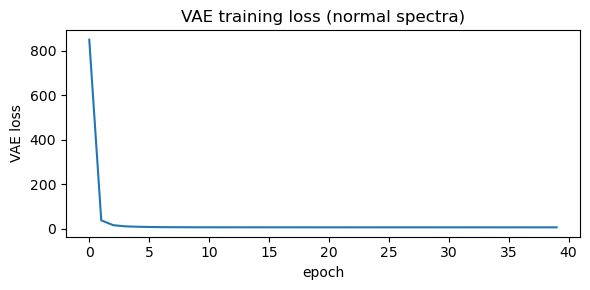

final VAE training loss: 7.30


In [7]:
# Read and run — no need to edit.  (Colab/T4-friendly; a few epochs is plenty on CPU too)
EPOCHS = 40
BATCH_SIZE = 32
LR = 1e-3

def train_autoencoder(model, X, epochs, batch_size, lr, loss_fn):
    """Reusable loop for both the VAE and the plain AE below."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X.shape[0]
    history = []
    pbar = tqdm(range(epochs), desc="training")
    for _ in pbar:
        order = torch.randperm(n)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            xb = X[order[start:start + batch_size]]
            loss = loss_fn(model, xb)          # forward + loss packaged per-model
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        history.append(epoch_loss / n)
        pbar.set_postfix(loss=f"{history[-1]:.2f}")
    return history

def vae_step(model, xb):
    recon, mu, logvar = model(xb)
    loss, _, _ = vae_loss(recon, xb, mu, logvar, BETA)
    return loss

vae = SpectrumVAE(LATENT_DIM).to(DEVICE)
vae_history = train_autoencoder(vae, X_train, EPOCHS, BATCH_SIZE, LR, vae_step)

plt.figure(figsize=(6, 3))
plt.plot(vae_history)
plt.xlabel("epoch"); plt.ylabel("VAE loss"); plt.title("VAE training loss (normal spectra)")
plt.tight_layout(); plt.show()
print(f"final VAE training loss: {vae_history[-1]:.2f}")


## Step 7 · Set the anomaly threshold — YOUR TURN ✏️

Now turn reconstruction error into a **flag**. First we measure the VAE's reconstruction error
on the **training (normal) spectra** — that tells us what "normal error" looks like. Anything
scoring **well above** that is suspicious.

A robust rule of thumb: set the threshold at a **high percentile of the training errors** — say
the **95th percentile**, so we expect to flag only ~5% of *normal* spectra as false alarms.

> **This is a sensitivity/specificity dial (Lecture 10 callback).** Raise the percentile → fewer
> false alarms but you miss more true anomalies (lower sensitivity). Lower it → catch more but
> cry wolf more often. There is no universal "right" number — it's a clinical trade-off you own.

Set **`THRESHOLD`** to the **95th percentile** of `train_errors` (use `np.percentile`).


In [8]:
# reconstruction error = per-spectrum mean squared error, scored deterministically from mu
def recon_error(model, X):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(X)
        recon = model.decode(mu)                 # use the mean (no random sampling) for scoring
    return ((recon - X) ** 2).mean(dim=1).cpu().numpy()

train_errors = recon_error(vae, X_train)         # what "normal" reconstruction error looks like

# ---- Blank 3: the anomaly threshold = the 95th percentile of the training errors ----
### BEGIN SOLUTION
THRESHOLD = np.percentile(train_errors, 95)
### END SOLUTION

# --- self-checks: do not edit ---
assert np.isfinite(THRESHOLD), "THRESHOLD must be a finite number"
assert train_errors.min() <= THRESHOLD < train_errors.max(), \
    "a percentile threshold must land inside the range of the training errors (not 0, not the max)"
print(f"training recon error: min {train_errors.min():.4f}  median {np.median(train_errors):.4f}"
      f"  max {train_errors.max():.4f}")
print(f"anomaly THRESHOLD (95th pct): {THRESHOLD:.4f}")


training recon error: min 0.0003  median 0.0011  max 0.0049
anomaly THRESHOLD (95th pct): 0.0022


## Step 8 · Score the held-out spectra & flag anomalies *(runs for you)*

Now score everything we held out and flag every spectrum whose error clears the threshold.


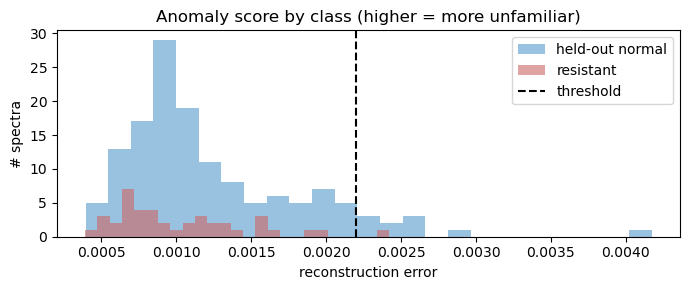

flagged 12 of 181 held-out spectra as anomalies
  of the flagged: 1 resistant, 11 normal
Scoring shapes check out.


In [9]:
# Read and run — no need to edit.
score_errors = recon_error(vae, X_score)
flagged = score_errors > THRESHOLD               # boolean anomaly flags

plt.figure(figsize=(7, 3))
for cls, name, color in [(0, "held-out normal", "#59c"), (1, "resistant", "#c66")]:
    plt.hist(score_errors[score_label == cls], bins=25, alpha=0.6, label=name, color=color)
plt.axvline(THRESHOLD, ls="--", color="k", label="threshold")
plt.xlabel("reconstruction error"); plt.ylabel("# spectra")
plt.title("Anomaly score by class (higher = more unfamiliar)")
plt.legend(); plt.tight_layout(); plt.show()

n_flag = int(flagged.sum())
print(f"flagged {n_flag} of {len(flagged)} held-out spectra as anomalies")
print(f"  of the flagged: {int(flagged[score_label == 1].sum())} resistant, "
      f"{int(flagged[score_label == 0].sum())} normal")

# --- self-checks: STRUCTURE only (so a shrunk smoke run still passes) ---
assert score_errors.shape == (len(score_idx),), "one reconstruction error per scored spectrum"
assert flagged.dtype == bool and 0 <= n_flag <= len(flagged), "flags are booleans; count is in range"
print("Scoring shapes check out.")


**Read it honestly.** The two histograms **overlap** — resistant spectra are *not* cleanly
separated from normal ones, exactly as warned. Reconstruction error is a **QC / novelty**
signal, not a resistance test. What you *have* built is a knob: move the threshold and you trade
false alarms against missed anomalies (Lecture 10). On a real instrument the "unfamiliar" cases
would be bad runs, contamination, or a new organism — and *those* the detector would catch.


## Step 9 · The latent map: VAE vs. plain autoencoder *(runs for you)*

Lecture 11's headline picture: a **plain AE** scatters its codes into islands with gaps that
decode to garbage, while a **VAE**'s KL term packs everything into one smooth, organized blob
around the origin. Let's reproduce it on **real spectra**. We train a plain AE (same sizes, no
`mu`/`logvar`, no KL) as read-and-run code, then plot both 2-D latent maps side by side.


training:   0%|          | 0/40 [00:00<?, ?it/s]

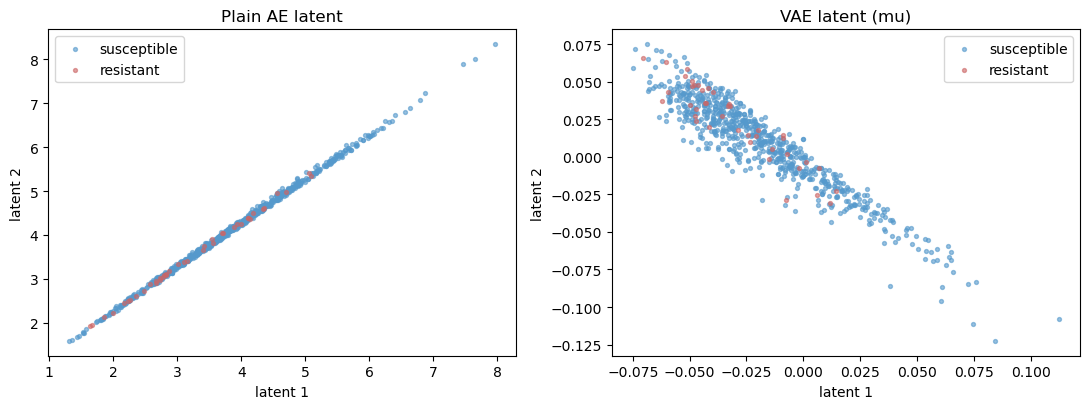

Both latent maps are 2-D: (738, 2) — compare the two panels above.


In [10]:
# Read and run — no need to edit.  A plain autoencoder: same shape, but NO KL term.
class SpectrumAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(INPUT_DIM, H1), nn.ReLU(),
                                 nn.Linear(H1, H2), nn.ReLU(),
                                 nn.Linear(H2, latent_dim))          # straight to a latent point
        self.dec = nn.Sequential(nn.Linear(latent_dim, H2), nn.ReLU(),
                                 nn.Linear(H2, H1), nn.ReLU(),
                                 nn.Linear(H1, INPUT_DIM), nn.Sigmoid())
    def encode(self, x): return self.enc(x)
    def forward(self, x): return self.dec(self.enc(x))

def ae_step(model, xb):
    return ((model(xb) - xb) ** 2).sum(dim=1).mean()      # reconstruction only, no KL

ae = SpectrumAE(LATENT_DIM).to(DEVICE)
ae_history = train_autoencoder(ae, X_train, EPOCHS, BATCH_SIZE, LR, ae_step)

# encode the full dataset with both models to compare their latent maps
X_all = torch.tensor(X, device=DEVICE)
with torch.no_grad():
    vae_latent = vae.encode(X_all)[0].cpu().numpy()       # use mu as the VAE's latent point
    ae_latent  = ae.encode(X_all).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, latent, title in [(axes[0], ae_latent, "Plain AE latent"),
                          (axes[1], vae_latent, "VAE latent (mu)")]:
    for cls, name, color in [(0, "susceptible", "#59c"), (1, "resistant", "#c66")]:
        m = y == cls
        ax.scatter(latent[m, 0], latent[m, 1], s=8, alpha=0.6, label=name, color=color)
    ax.set_title(title); ax.set_xlabel("latent 1"); ax.set_ylabel("latent 2"); ax.legend()
plt.tight_layout(); plt.show()

# --- self-checks: STRUCTURE only ---
assert vae_latent.shape == (len(X), 2), f"VAE latent must be (n, 2); got {vae_latent.shape}"
assert ae_latent.shape == (len(X), 2), f"AE latent must be (n, 2); got {ae_latent.shape}"
print("Both latent maps are 2-D:", vae_latent.shape, "— compare the two panels above.")


Look at the two panels. The **VAE**'s codes cluster tightly and smoothly around the origin
(the KL term's doing) — a space you can sample from and walk across. The **plain AE**'s codes
sprawl with gaps; pick a random point there and the decoder likely spits out nonsense. *That*
smoothness is why the VAE is the one you can generate and interpolate with next.


## Step 10 · The fun payoff — morph one spectrum into another 🧬 *(runs for you)*

Because the VAE's latent space is smooth, a **straight line** between two spectra's codes decodes
to a sequence of **plausible in-between spectra**. Pick two susceptible spectra, encode them,
walk the line, and decode each step — one spectrum literally morphs into the other.


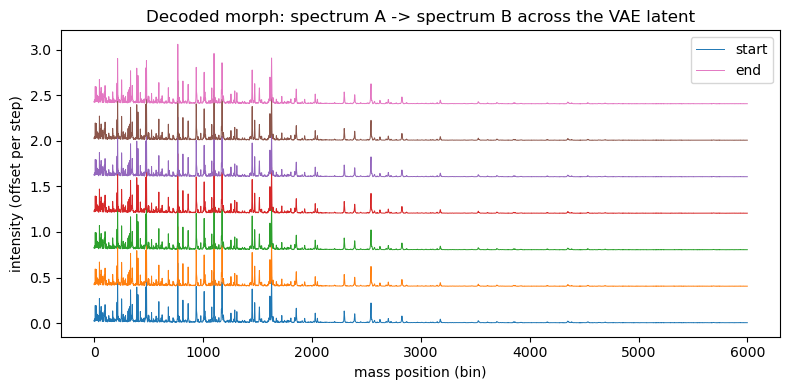

Interpolation returned (7, 6000) — 7 decoded spectra of length 6000.


In [11]:
# Read and run — no need to edit.
def interpolate_spectra(model, x1, x2, n_steps=7):
    """Decode evenly-spaced latent points on the line from x1's code to x2's code."""
    model.eval()
    with torch.no_grad():
        z1, _ = model.encode(x1.unsqueeze(0))
        z2, _ = model.encode(x2.unsqueeze(0))
        alphas = torch.linspace(0, 1, n_steps, device=z1.device).unsqueeze(1)
        z_path = (1 - alphas) * z1 + alphas * z2          # (n_steps, latent_dim)
        decoded = model.decode(z_path)                    # (n_steps, 6000)
    return decoded.cpu().numpy()

a_idx, b_idx = train_normal_idx[0], train_normal_idx[1]
morph = interpolate_spectra(vae, X_all[a_idx], X_all[b_idx], n_steps=7)

plt.figure(figsize=(8, 4))
offset = 0.0
for i, spec in enumerate(morph):
    plt.plot(spec + offset, linewidth=0.7,
             label=("start" if i == 0 else "end" if i == len(morph) - 1 else None))
    offset += 0.4                                          # stack the steps so you see the morph
plt.xlabel("mass position (bin)"); plt.ylabel("intensity (offset per step)")
plt.title("Decoded morph: spectrum A -> spectrum B across the VAE latent")
plt.legend(); plt.tight_layout(); plt.show()

# --- self-checks: STRUCTURE only ---
assert morph.shape == (7, 6000), f"interpolation must return (7, 6000); got {morph.shape}"
assert np.isfinite(morph).all(), "every decoded spectrum must be finite"
print("Interpolation returned", morph.shape, "— 7 decoded spectra of length 6000.")


## What just happened & the teachable moments

You built the whole Lecture 11 story on real clinical spectra:

- trained a **VAE on normal spectra only** and used **reconstruction error** as a QC / anomaly
  score — an honest **novelty** detector, not a resistance classifier;
- set the flag with a **threshold**, which is a **sensitivity/specificity choice** (Lecture 10);
- saw the **VAE latent** come out smooth and organized vs. the **plain AE**'s scattered islands;
- **generated** by decoding latent points and **interpolated** one spectrum into another.

**Three knobs, three failure modes to remember:**

| Knob | Turn it wrong | What breaks |
|---|---|---|
| KL weight `BETA` | too **high** | reconstructions go **blurry** (tidiness beats accuracy) |
| bottleneck `LATENT_DIM` | too **big** | everything reconstructs well → **anomaly detector stops working** |
| `THRESHOLD` | too high / too low | **misses anomalies** / **too many false alarms** (sens vs. spec) |


## Discussion D4 (10 min)

**What does "abnormal" look like in your instrument's output — and would reconstruction error
catch it before a human does?**

Think about your own assay or QC stream:
- What are the **normal** runs you'd train on, and what would count as an **anomaly** (a bad
  injection, contamination, a new organism, a drifting instrument)?
- Where would you set the **threshold** — would you rather over-flag (catch everything, annoy
  the analyst) or under-flag (fewer false alarms, risk a miss)?
